## Analyzing Cremona from open street map data

In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import pandas as pd
import numpy as np
import networkx as nx
import shapely


In [ ]:
# Let's get the data from Open Street Map
place_name = "Cremona, Italy"
graph = ox.graph_from_place(place_name, network_type='drive', which_result= 2)
prj_G = ox.projection.project_graph(graph)


In [ ]:
fig, ax = plt.subplots()
ox.plot_graph(prj_G, ax=ax, node_size= 2, node_color='black')

In [ ]:
# Compute the basic stats
stats = ox.basic_stats(prj_G)
stats

In [ ]:
# Plot degree distribution
cat = stats['streets_per_node_proportions'].keys()
freq = stats['streets_per_node_proportions'].values()

plt.bar(cat,freq)
plt.ylim(0,1)



In [ ]:
# Let's create a GeoDataFrame from the graph
gdf_nodes, gdf_edges = ox.graph_to_gdfs(prj_G)
gdf_nodes.head()

In [ ]:
gdf_nodes.crs

In [ ]:
# Select specific nodes with lat and lon
lat, lon = 45.139614, 10.026505
start_point = shapely.geometry.Point(lon, lat)
start_point_gdf = gpd.GeoDataFrame(geometry=[start_point], crs= "EPSG:4326")
start_point_gdf = start_point_gdf.to_crs(gdf_nodes.crs)
print(start_point_gdf.geometry.x[0], start_point_gdf.geometry.y[0])
start = ox.distance.nearest_nodes(prj_G, start_point_gdf.geometry.x[0], start_point_gdf.geometry.y[0])
print(start)

In [ ]:
gdf_nodes.loc[start]

In [ ]:
# find the gdf_node corresponding to the start node
start_node = gdf_nodes.loc[start]

In [ ]:
#Highlighting the start node by plotting nodes and edges and not the original graph
#plot gdb_nodes and gdf_edges
fig, ax = plt.subplots(figsize=(20,20))
gdf_nodes.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=1, edgecolor='black', zorder=1)
#plot the start node
ax.scatter(start_node['x'], start_node['y'], color='red', s=100)

In [ ]:
arrive_lat, arrive_lon = 45.12868, 10.00280
arrive_point = shapely.geometry.Point(arrive_lon, arrive_lat)
arrive_point_gdf = gpd.GeoDataFrame(geometry=[arrive_point], crs= "EPSG:4326")
arrive_point_gdf = arrive_point_gdf.to_crs(gdf_nodes.crs)
print(arrive_point_gdf.geometry.x[0], arrive_point_gdf.geometry.y[0])
arrive = ox.distance.nearest_nodes(prj_G, arrive_point_gdf.geometry.x[0], arrive_point_gdf.geometry.y[0])

arrive_node = gdf_nodes.loc[arrive]

In [ ]:
# Plotssss
fig, ax = plt.subplots(figsize=(20,20))
gdf_nodes.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=1, edgecolor='black', zorder=1)
#plot the start node
ax.scatter(start_node['x'], start_node['y'], color='red', s=100)
#plot the arrive node
ax.scatter(arrive_node['x'], arrive_node['y'], color='blue', s=100)


Took me 2 hours to paint red and blue dots on a map. not proud of this.
### Shortest path

In [ ]:
gdf_edges.head()

In [ ]:
# Let's find the shortest path
route = nx.shortest_path(prj_G, start, arrive, weight='length')
route_edges = list(zip(route, route[1:]))

print(route_edges)
ec = ['r' if edge in route_edges else 'blue' for edge in prj_G.edges()]
es = [3 if edge in route_edges else 1 for edge in prj_G.edges()]
#print(ec)

In [ ]:

#plot
fig, ax = plt.subplots(figsize=(20,20))
gdf_nodes.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=es, edgecolor= ec, zorder=1)
#plot the start node
ax.scatter(start_node['x'], start_node['y'], color='red', s=50)
#plot the arrive node
ax.scatter(arrive_node['x'], arrive_node['y'], color='red', s=50)
#plot the route

# Length of the route
routegdf = ox.routing.route_to_gdf(prj_G, route, weight='length')
lenght = int(routegdf['length'].sum())
print("The length of the route is: ", lenght, "m")


In [ ]:
# Convert the route to CRS 4326
routegdf = routegdf.to_crs("EPSG:4326")

In [ ]:
# export 
routegdf.to_file("route.geojson", driver='GeoJSON')

Everything looks good, of course some roads are not drivable due to traffic restrictions, but the route is correct.

In [ ]:
# Let's use time as weight, and find the shortest path, we need to insert the speed of the roads
prj_G_speed = ox.add_edge_speeds(prj_G)
prj_G_speed = ox.add_edge_travel_times(prj_G_speed)

In [ ]:
edges = ox.graph_to_gdfs(prj_G_speed, nodes=False, edges=True)
edges['highway'] = edges['highway'].astype(str)
edges.groupby("highway")[["length", "speed_kph", "travel_time"]].mean().round(1)

In [ ]:
edges.head()

In [ ]:
# Let's find the shortest path
route2 = nx.shortest_path(prj_G_speed, start, arrive, weight='travel_time')
route_edges2 = list(zip(route2, route2[1:]))

ec2 = ['r' if edge in route_edges2 else 'blue' for edge in prj_G_speed.edges()]
es2 = [3 if edge in route_edges2 else 1 for edge in prj_G_speed.edges()]

In [ ]:
#plot
fig, ax = plt.subplots(figsize=(20,20))
gdf_nodes.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=es2, edgecolor= ec2, zorder=1)
#plot the start node
ax.scatter(start_node['x'], start_node['y'], color='red', s=50)
#plot the arrive node
ax.scatter(arrive_node['x'], arrive_node['y'], color='red', s=50)

# Length of the route
routegdf2 = ox.routing.route_to_gdf(prj_G_speed, route2, weight='travel_time')
lenght2 = int(routegdf2['length'].sum())

print("The length of the route is: ", lenght2, "m")

In [ ]:
# Compute the time of the route for both cases
routegdf = ox.routing.route_to_gdf(prj_G_speed, route, weight='length')

time1 = int(routegdf['travel_time'].sum())
time2 = int(routegdf2['travel_time'].sum())

print("The time of the route 1 is: ", time1, "s")
print("The time of the route 2 is: ", time2, "s")

In [ ]:
# Convert the route to CRS 4326
routegdf2 = routegdf2.to_crs("EPSG:4326")
# export the route to GeoJSON
routegdf2.to_file("route2.geojson", driver='GeoJSON')


Everything looks very good, let's try to adjust to how traffic is in Cremona, and see if we can get a better route.


In [ ]:
# Traffic, very naive approach: use inbetween centrality to simulate traffic
bc = nx.betweenness_centrality(prj_G_speed, weight='length')
edge_bc = nx.edge_betweenness_centrality(prj_G_speed, weight='length')


In [ ]:
nx.set_node_attributes(prj_G_speed, bc, 'bc')
nx.set_edge_attributes(prj_G_speed, edge_bc, 'edge_bc')

gdf_nodes = ox.graph_to_gdfs(prj_G_speed, edges=False)
gdf_edges = ox.graph_to_gdfs(prj_G_speed, nodes=False, edges=True)


In [ ]:
gdf_nodes.head()

In [ ]:
#  centrality
nc = gdf_nodes['bc']
ns = 1+ gdf_nodes['bc']*1000

ec = gdf_edges['edge_bc']
es = 1+ gdf_edges['edge_bc']*20

fig, ax = plt.subplots(figsize=(20,20))
gdf_nodes.plot(ax=ax, c = nc, zorder=2, markersize= ns, cmap='viridis')
gdf_edges.plot(ax=ax, linewidth= es, zorder=1, cmap='viridis', edgecolor='black')



In [ ]:
# I can use bc to influence the speed of the roads
max = gdf_edges['edge_bc'].max()
min = gdf_edges['edge_bc'].min()

gdf_edges['edge_bc'] = (gdf_edges['edge_bc'] - min)/(max - min)
print(gdf_edges['edge_bc'].max(), gdf_edges['edge_bc'].min())

In [ ]:
gdf_edges['speed_kph'].head()

In [ ]:
# speed of the roads using edge_bc
gdf_edges['traffic_speed'] = gdf_edges['speed_kph']*(1-gdf_edges['edge_bc']*0.7)
# compute time (in seconds) to travel each edge
gdf_edges['traffic_time'] = gdf_edges['length'] / (gdf_edges['traffic_speed'] * 1000 / 3600)
prj_G_traffic = ox.graph_from_gdfs(gdf_nodes, gdf_edges)


In [ ]:
gdf_edges.head()

In [ ]:
# shortest path
route_traffic = nx.shortest_path(prj_G_traffic, start, arrive, weight='traffic_time')
route_edges_traffic = list(zip(route_traffic, route_traffic[1:]))

ec_traffic = ['r' if edge in route_edges_traffic else 'blue' for edge in prj_G_traffic.edges()]
es_traffic = [3 if edge in route_edges_traffic else 1 for edge in prj_G_traffic.edges()]

In [ ]:
ox.plot_graph_route(prj_G, route_traffic, route_linewidth=6, node_size=0)
ox.plot_graph_route(prj_G, route, route_linewidth=6, node_size=0, bgcolor='k', route_color='r')
ox.plot_graph_route(prj_G, route2, route_linewidth=6, node_size=0, bgcolor='k', route_color='r')

In [ ]:
#plot all routes
all_routes = [route, route2, route_traffic]
ox.plot_graph_routes(prj_G_traffic, all_routes, route_color='r', route_linewidth=6, node_size=0)


In [ ]:
# Length of the route
routegdf_traffic = ox.routing.route_to_gdf(prj_G_traffic, route_traffic, weight='length')
lenght_traffic = int(routegdf_traffic['length'].sum())
print("The length of the route is: ", lenght_traffic, "m")


In [ ]:
# time of the route
time_traffic = int(routegdf_traffic['traffic_time'].sum())
print("The time of the route is: ", time_traffic, "s")

In [ ]:
#export the route to GeoJSON
routegdf_traffic = routegdf_traffic.to_crs("EPSG:4326")
routegdf_traffic.to_file("route_traffic.geojson", driver='GeoJSON')

Looks like the **traffic** is not changing the route, time still has increased soooo I guess it is fine


### Let's add traffic lights


In [ ]:
# search for traffic lights
traffic_lights = ox.features_from_place(place_name, tags={'highway':'traffic_signals'}, which_result=2)

In [ ]:
traffic_lights.head()

In [ ]:
traffic_lights.to_crs(gdf_nodes.crs, inplace=True)
#plot
fig, ax = plt.subplots(figsize=(8,8))
gdf_nodes.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=1, edgecolor='black', zorder=1)
traffic_lights.plot(ax=ax, color='red', zorder=3)


This looks way more accurate then what I expected, crazy

In [ ]:
# Let's add the traffic lights to the nodes
# find nearest node ALL IN ONCE
nearest_nodes = ox.distance.nearest_nodes(prj_G, traffic_lights.geometry.x, traffic_lights.geometry.y)
gdf_nodes['traffic_lights'] = gdf_nodes.index.isin(nearest_nodes)
### way more efficient

In [ ]:
'''
Not efficient
# Let's add the traffic lights to the nodes
gdf_nodes['traffic_lights'] = False
for index, row in traffic_lights.iterrows():
    nearest_node = ox.distance.nearest_nodes(prj_G, row.geometry.x, row.geometry.y)
    gdf_nodes.loc[nearest_node, 'traffic_lights'] = True
'''

In [ ]:
# traffic lights to the edges  ALL IN ONCE
gdf_edges.index.get_level_values(1)
gdf_edges['traffic_lights'] = gdf_edges.index.get_level_values(1).isin(gdf_nodes[gdf_nodes['traffic_lights']].index)


prj_G_traffic_lights = ox.graph_from_gdfs(gdf_nodes, gdf_edges)

gdf_edges.head()
# nice way of indexing ;)

In [ ]:
'''
prj_G_traffic_lights = ox.graph_from_gdfs(gdf_nodes, gdf_edges)

# let's create a new edge attribute that says if there is a traffic light in the following node
gdf_edges['traffic_lights'] = False
gdf_edges = gdf_edges.sort_index() # Otherwise, it will raise a warning of performance
for u, v,  data in prj_G_traffic_lights.edges(data=True): # REMEMBER THIS WAY OF INDEXING BECAUSE IT TOOK 2 HOURS
    if gdf_nodes.loc[v, 'traffic_lights']:
        gdf_edges.loc[(u,v), 'traffic_lights'] = True
'''

In [ ]:
#plot traffic lights
nc = ['red' if node else 'green' for node in gdf_nodes['traffic_lights']]
ec = ['red' if edge else 'blue' for edge in gdf_edges['traffic_lights']]
fig, ax = plt.subplots(figsize=(12,12))
gdf_nodes.plot(ax=ax, color=nc, zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=1, edgecolor=ec, zorder=1)


VERY NICE

In [ ]:
# Let's add a velocity penalty for traffic lights to the existing traffic
gdf_edges['traffic_speed'] = gdf_edges['speed_kph']*(1-gdf_edges['edge_bc']*0.7)*(1-gdf_edges['traffic_lights']*0.2)
gdf_edges['traffic_time'] = gdf_edges['length'] / (gdf_edges['traffic_speed'] * 1000 / 3600)

gdf_edges.head()

In [ ]:
# shortest path
prj_G_traffic_lights = ox.graph_from_gdfs(gdf_nodes, gdf_edges)
route_traffic_lights = nx.shortest_path(prj_G_traffic_lights, start, arrive, weight='traffic_time')
route_edges_traffic_lights = list(zip(route_traffic_lights, route_traffic_lights[1:]))


In [ ]:
ox.plot_graph_route(prj_G_traffic_lights, route_traffic_lights, route_linewidth=6, node_size=0)
# Length of the route
routegdf_traffic_lights = ox.routing.route_to_gdf(prj_G_traffic_lights, route_traffic_lights, weight='length')
lenght_traffic_lights = int(routegdf_traffic_lights['length'].sum())
print("The length of the route is: ", lenght_traffic_lights, "m")
time_traffic_lights = int(routegdf_traffic_lights['traffic_time'].sum())
print("The time of the route is: ", time_traffic_lights, "s")


In [ ]:
ec_traffic_lights = ['r' if edge in routegdf_traffic_lights.index else 'blue' for edge in gdf_edges.index]
es_traffic_lights = [3 if edge in routegdf_traffic_lights.index else 1 for edge in gdf_edges.index]
#plot
fig, ax = plt.subplots(figsize=(12,12))
gdf_nodes.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=es_traffic_lights, edgecolor= ec_traffic_lights, zorder=1)
ax.scatter(start_node['x'], start_node['y'], color='red', s=50)
ax.scatter(arrive_node['x'], arrive_node['y'], color='red', s=50)



In [ ]:
#export the route to GeoJSON
routegdf_traffic_lights = routegdf_traffic_lights.to_crs("EPSG:4326")
routegdf_traffic_lights.to_file("route_traffic_lights.geojson", driver='GeoJSON')

Maybe this makes absolutely no sense, but it is funny
### Restricted traffic areas


In [ ]:
# let's create a circle around the city center which is a restricted traffic area
center_lat, center_lon = 45.13421, 10.02455
center_point = shapely.geometry.Point(center_lon, center_lat)
center_point_gdf = gpd.GeoDataFrame(geometry=[center_point], crs="EPSG:4326")
center_point_gdf = center_point_gdf.to_crs(gdf_nodes.crs)
# add a buffer of 500 meters
buffer = center_point_gdf.buffer(300)



In [ ]:
f, ax = plt.subplots(figsize=(8,8))
gdf_nodes.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=1, edgecolor='black', zorder=1)
center_point_gdf.plot(ax=ax, color='red', zorder=3)
buffer.plot(ax=ax, color='red', alpha=0.5, zorder=3)

Perfect, now the restricted area is the red circle, I have to make it inaccesible

### Filter nodes and edges that are not within the buffer
Ok so in order to remember what is going on:
2 ways of filtering:
- *Using the within() function:* 

    selecting the nodes and edges in one line, looks good BUT then it is needed to filter the edges that have a missing node
- *Using the clip() function:*

    maybe one more step because we have both clip() and isin() but it avoids the missing node problem

In [ ]:
# Filter nodes and edges that are not within the buffer
gdf_nodes_ztl = gdf_nodes[~gdf_nodes.geometry.within(buffer.geometry[0])]
gdf_edges_ztl = gdf_edges[~gdf_edges.geometry.within(buffer.geometry[0])]

# Ensure all edges are valid
gdf_edges_ztl = gdf_edges_ztl[gdf_edges_ztl.is_valid]

In [ ]:
#alternative way of filtering, using clip() {Thanks Thomas}
#exclude nodes and edges that are within the buffer
gdf_nodes_clip = gdf_nodes.clip(buffer.geometry[0])
gdf_edges_clip = gdf_edges.clip(buffer.geometry[0])

gdf_nodes_ztl = gdf_nodes[~gdf_nodes.index.isin(gdf_nodes_clip.index)]
gdf_edges_ztl = gdf_edges[~gdf_edges.index.isin(gdf_edges_clip.index)]



#plot
fig, ax = plt.subplots(1 , 1, figsize=(12,12))
gdf_nodes_ztl.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges_ztl.plot(ax=ax, linewidth=1, edgecolor='black', zorder=1)
#center_point_gdf.plot(ax=ax, color='red', zorder=3)
buffer.plot(ax=ax, color='red', alpha=0.5, zorder=3)


In [ ]:
'''
Less efficient, because we have apply lambda function for each row

# I want a new graph without the buffer

gdf_nodes_ztl = gdf_nodes[gdf_nodes.apply(lambda x: x.geometry.within(buffer.geometry[0]), axis=1) == False]
gdf_edges_ztl = gdf_edges[gdf_edges.apply(lambda x: x.geometry.within(buffer.geometry[0]), axis=1) == False]
gdf_edges_ztl = gdf_edges_ztl[gdf_edges_ztl.is_valid]
'''

In [ ]:
#check for edges with a missing node
u = set(gdf_edges_ztl.index.get_level_values(0))
v = set(gdf_edges_ztl.index.get_level_values(1))
missing_nodes = u.union(v) - set(gdf_nodes_ztl.index)
print(missing_nodes)
# only include edges that have both nodes in the filtered nodes
gdf_edges_ztl = gdf_edges_ztl[gdf_edges_ztl.index.get_level_values(0).isin(gdf_nodes_ztl.index) & gdf_edges_ztl.index.get_level_values(1).isin(gdf_nodes_ztl.index)] 

In [ ]:
#plot
fig, ax = plt.subplots(1 , 1, figsize=(12,12))
gdf_nodes_ztl.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges_ztl.plot(ax=ax, linewidth=1, edgecolor='black', zorder=1)
#center_point_gdf.plot(ax=ax, color='red', zorder=3)
buffer.plot(ax=ax, color='red', alpha=0.5, zorder=3)

In [ ]:
# Let's create a new graph
prj_G_ztl = ox.graph_from_gdfs(gdf_nodes_ztl, gdf_edges_ztl )
#route
route_ztl = nx.shortest_path(prj_G_ztl, start, arrive, weight='traffic_time')
routegdf_ztl = ox.routing.route_to_gdf(prj_G_ztl, route_ztl, weight='length')

In [ ]:
#plot
ec_ztl = ['r' if edge in routegdf_ztl.index else 'blue' for edge in gdf_edges_ztl.index]
es_ztl = [3 if edge in routegdf_ztl.index else 1 for edge in gdf_edges_ztl.index]

fig, ax = plt.subplots(figsize=(20,20))
gdf_nodes_ztl.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges_ztl.plot(ax=ax, linewidth=es_ztl, edgecolor= ec_ztl, zorder=1)
#plot the start node
ax.scatter(start_node['x'], start_node['y'], color='red', s=50)
#plot the arrive node
ax.scatter(arrive_node['x'], arrive_node['y'], color='red', s=50)

time_ztl = int(routegdf_ztl['traffic_time'].sum())
print("The time of the route is: ", time_ztl, "s")

Actually, very solid results!

In [ ]:
# Length and time
lenght_ztl = int(routegdf_ztl['length'].sum())
print("The length of the route is: ", lenght_ztl, "m")
time_ztl = int(routegdf_ztl['traffic_time'].sum())
print("The time of the route is: ", time_ztl, "s")

In [ ]:
#export 
routegdf_ztl = routegdf_ztl.to_crs("EPSG:4326")
routegdf_ztl.to_file("route_ztl.geojson", driver='GeoJSON')

In [ ]:
# Let's see if I can increase the traffic of the city center
buffer_traffic = center_point_gdf.buffer(1000)
#plot
fig, ax = plt.subplots(figsize=(8,8))
gdf_nodes_ztl.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges_ztl.plot(ax=ax, linewidth=1, edgecolor='black', zorder=1)
buffer_traffic.plot(ax=ax, color='red', alpha=0.5, zorder=3)

Once again we have a red circle, but this time it is a traffic center, we can use either within() or clip() to filter the nodes and edges

In [ ]:
gdf_edges_clip = gdf_edges_ztl.clip(buffer_traffic.geometry[0])

gdf_edges_ztl['traffic_center'] = gdf_edges_ztl.index.isin(gdf_edges_clip.index)
print(gdf_edges_ztl['traffic_center'].sum())
print(sum(gdf_edges_ztl['traffic_center'] == 0))


In [ ]:
'''
# create a new column in the edges that says if the edge is in the buffer_traffic
gdf_edges_ztl['traffic_center'] = False
gdf_edges_ztl = gdf_edges_ztl.sort_index()

gdf_edges_ztl['traffic_center'] = gdf_edges_ztl.apply(lambda x: x.geometry.within(buffer_traffic.geometry[0]), axis=1)

gdf_edges_ztl['traffic_center'].sum()
'''

In [ ]:
# Let's add a velocity penalty for traffic lights to the existing traffic
gdf_edges_ztl['traffic_speed'] = gdf_edges_ztl['speed_kph']*(1-gdf_edges_ztl['edge_bc']*0.7)*(1-gdf_edges_ztl['traffic_lights']*0.2)*(1-gdf_edges_ztl['traffic_center']*0.7)
gdf_edges_ztl['traffic_time'] = gdf_edges_ztl['length'] / (gdf_edges_ztl['traffic_speed'] * 1000 / 3600)

In [ ]:
# shortest path
prj_G_ztl_traffic = ox.graph_from_gdfs(gdf_nodes_ztl, gdf_edges_ztl)
route_ztl_traffic = nx.shortest_path(prj_G_ztl_traffic, start, arrive, weight='traffic_time')
routegdf_ztl = ox.routing.route_to_gdf(prj_G_ztl_traffic, route_ztl_traffic, weight='length')

In [ ]:
#plot
ec_ztl_traffic = ['r' if edge in routegdf_ztl.index else 'blue' for edge in gdf_edges_ztl.index]
es_ztl_traffic = [3 if edge in routegdf_ztl.index else 1 for edge in gdf_edges_ztl.index]

fig, ax = plt.subplots(figsize=(12,12))
gdf_nodes_ztl.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges_ztl.plot(ax=ax, linewidth=es_ztl_traffic, edgecolor= ec_ztl_traffic, zorder=1)
#plot the start node
ax.scatter(start_node['x'], start_node['y'], color='red', s=50)
#plot the arrive node
ax.scatter(arrive_node['x'], arrive_node['y'], color='red', s=50)

time_ztl = int(routegdf_ztl['traffic_time'].sum())
print("The time of the route is: ", time_ztl, "s")

In [ ]:
routegdf_ztl['traffic_speed'].mean()

In [ ]:
#export
routegdf_ztl = routegdf_ztl.to_crs("EPSG:4326")
routegdf_ztl.to_file("route_ztl_traffic.geojson", driver='GeoJSON')

In [ ]:
# start and arrive swapped
route_ztl_traffic_reverse = nx.shortest_path(prj_G_ztl_traffic, arrive, start, weight='traffic_time')
routegdf_ztl_reverse = ox.routing.route_to_gdf(prj_G_ztl_traffic, route_ztl_traffic_reverse, weight='length')

In [ ]:
#plot
ec_ztl_traffic_reverse = ['r' if edge in routegdf_ztl_reverse.index else 'blue' for edge in gdf_edges_ztl.index]
es_ztl_traffic_reverse = [3 if edge in routegdf_ztl_reverse.index else 1 for edge in gdf_edges_ztl.index]

fig, ax = plt.subplots(figsize=(12,12))
gdf_nodes_ztl.plot(ax=ax, color='green', zorder=2, markersize=2)
gdf_edges_ztl.plot(ax=ax, linewidth=es_ztl_traffic_reverse, edgecolor= ec_ztl_traffic_reverse, zorder=1)

ax.scatter(arrive_node['x'], arrive_node['y'], color='green', s=50)
ax.scatter(start_node['x'], start_node['y'], color='red', s=50)

time_ztl_reverse = int(routegdf_ztl_reverse['traffic_time'].sum())
print("The time of the route is: ", time_ztl_reverse, "s")



In [ ]:
#export
routegdf_ztl_reverse = routegdf_ztl_reverse.to_crs("EPSG:4326")
routegdf_ztl_reverse.to_file("route_ztl_traffic_reverse.geojson", driver='GeoJSON')

I very like this road, but let's try to change start and arrive points


In [ ]:
#randomly pickiing a node
random_start = np.random.choice(gdf_nodes.index)
random_start_node = gdf_nodes.loc[random_start]

random_arrive = np.random.choice(gdf_nodes.index)
random_arrive_node = gdf_nodes.loc[random_arrive]

f , ax = plt.subplots(figsize=(8,8))
gdf_nodes.plot(ax=ax, color='black', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth=1, edgecolor='black', zorder=1)
ax.scatter(random_start_node['x'], random_start_node['y'], color='green', s=50)
ax.scatter(random_arrive_node['x'], random_arrive_node['y'], color='red', s=50)


In [ ]:
# shortest path
route_random = nx.shortest_path(prj_G_ztl_traffic, random_start, random_arrive, weight='traffic_time')
routegdf_random = ox.routing.route_to_gdf(prj_G_ztl_traffic, route_random, weight='length')


ec_random = ['r' if edge in routegdf_random.index else 'blue' for edge in gdf_edges.index]
es_random = [3 if edge in routegdf_random.index else 1 for edge in gdf_edges.index]

f, ax = plt.subplots(figsize=(20,20))
gdf_nodes.plot(ax=ax, color='black', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth= es_random, edgecolor=ec_random, zorder=1)

r_len = int(routegdf_random['length'].sum())
r_time = int(routegdf_random['traffic_time'].sum())
avg_speed = routegdf_random['traffic_speed'].mean()

print("The length of the route is: ", r_len, "m")
print("The time of the route is: ", r_time, "s")
print("The average speed of the route is: ", avg_speed, "km/h")

In [ ]:
#bbox that surrounds the route 
route_gdf = gdf_edges.loc[routegdf_random.index]


minx, miny, maxx, maxy = route_gdf.total_bounds
print(minx, miny, maxx, maxy)
#add a bit of margin
minx = minx*0.999
miny = miny*0.9999
maxx = maxx*1.001
maxy = maxy*1.0001






In [ ]:
#plot 
f, ax = plt.subplots(figsize=(8,8))
gdf_nodes.plot(ax=ax, color='black', zorder=2, markersize=2)
gdf_edges.plot(ax=ax, linewidth= es_random, edgecolor=ec_random, zorder=1)


ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)


In [ ]:
nodes_gnn = gdf_nodes_ztl.copy()
edges_gnn = gdf_edges_ztl.copy()
#save nodes and edges to GeoJSON
nodes_gnn.to_file("nodes_gnn.geojson", driver='GeoJSON')
edges_gnn.to_file("edges_gnn.geojson", driver='GeoJSON')

In [ ]:
FINE 

# ----- FROM HERE ON LOOK AT NOTEBOOK CR - 2 --------
This part regards preparing the datasets for ML models and adding a second city to the model, therefore it will be pretty much the same  data processing as the first part 



In [2]:
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import pandas as pd
import numpy as np
import networkx as nx
import shapely
from sklearn.preprocessing import StandardScaler, MinMaxScaler 

In [18]:
place_name = "Cremona, Italy"
graph = ox.graph_from_place(place_name, network_type='drive', which_result= 2)
prj_G = ox.projection.project_graph(graph)
prj_G = ox.add_edge_speeds(prj_G)
prj_G = ox.add_edge_travel_times(prj_G)
gdf_nodes, gdf_edges = ox.graph_to_gdfs(prj_G)


In [ ]:
#BC
bc = nx.betweenness_centrality(prj_G, weight='length')
edge_bc = nx.edge_betweenness_centrality(prj_G, weight='length')
scaler = MinMaxScaler()
# scale the values between 0 and 1
bc = scaler.fit_transform(pd.DataFrame(bc.values()))
edge_bc = scaler.fit_transform(pd.DataFrame(edge_bc.values()))

In [24]:
gdf_nodes['bc'] = bc
gdf_edges['edge_bc'] = edge_bc

In [30]:
# get traffic lights
traffic_lights = ox.features_from_place(place_name, tags={'highway':'traffic_signals'}, which_result=2)
traffic_lights = traffic_lights.to_crs(gdf_nodes.crs)
# nearest nodes
nearest_nodes = ox.distance.nearest_nodes(prj_G, traffic_lights.geometry.x, traffic_lights.geometry.y)
gdf_nodes['traffic_lights'] = gdf_nodes.index.isin(nearest_nodes)
gdf_edges['traffic_lights'] = gdf_edges.index.get_level_values(1).isin(gdf_nodes[gdf_nodes['traffic_lights']].index)

In [57]:
center_point = shapely.geometry.Point(10.02455, 45.13421)
center_point_gdf = gpd.GeoDataFrame(geometry=[center_point], crs="EPSG:4326")
center_point_gdf = center_point_gdf.to_crs(gdf_nodes.crs)
# add a buffer of 500 meters
buffer = center_point_gdf.buffer(500)
gdf_edges_clip = gdf_edges.clip(buffer.geometry[0])
gdf_edges['traffic_center'] = gdf_edges.index.isin(gdf_edges_clip.index)

In [65]:
gdf_edges['traffic_speed'] = gdf_edges['speed_kph']*(1-gdf_edges['edge_bc']*0.7)*(1-gdf_edges['traffic_lights']*0.2)*(1-gdf_edges['traffic_center']*0.7)
gdf_edges['traffic_time'] = gdf_edges['length'] / (gdf_edges['traffic_speed'] * 1000 / 3600)

In [67]:
#save to GeoJSON
gdf_nodes.to_file("nodes_CR.geojson", driver='GeoJSON')
gdf_edges.to_file("edges_CR.geojson", driver='GeoJSON')


<Axes: >

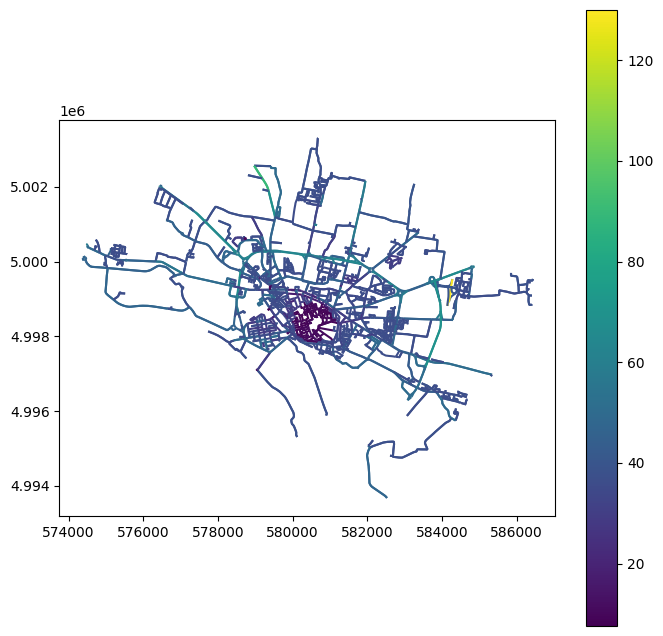

In [79]:
f , ax = plt.subplots(figsize=(8,8))
gdf_edges.plot(column='traffic_speed',cmap = 'viridis', legend=True, ax = ax)
#buffer.plot(ax=ax, color='red', alpha=0.5)

Let's try to download another city to check if the model is generalizing


In [69]:
new_place_name = "Piacenza, Emilia-Romagna, Italy"
new_graph = ox.graph_from_place(new_place_name, network_type='drive', which_result= 2)
new_graph = ox.project_graph(new_graph)
new_graph = ox.add_edge_speeds(new_graph)
new_graph = ox.add_edge_travel_times(new_graph)
new_gdf_nodes = ox.graph_to_gdfs(new_graph, edges=False)
new_gdf_edges = ox.graph_to_gdfs(new_graph, nodes=False, edges=True)


In [73]:
#BC
new_bc = nx.betweenness_centrality(new_graph, weight='length')
new_edge_bc = nx.edge_betweenness_centrality(new_graph, weight='length')
new_bc = scaler.fit_transform(pd.DataFrame(new_bc.values()))
new_edge_bc = scaler.fit_transform(pd.DataFrame(new_edge_bc.values()))

In [74]:
new_gdf_nodes['bc'] = new_bc
new_gdf_edges['edge_bc'] = new_edge_bc

In [80]:
# get traffic lights
new_traffic_lights = ox.features_from_place(new_place_name, tags={'highway':'traffic_signals'}, which_result=2)
new_traffic_lights = new_traffic_lights.to_crs(new_gdf_nodes.crs)
# find nearest node ALL IN ONCE
nearest_nodes = ox.distance.nearest_nodes(new_graph, new_traffic_lights.geometry.x, new_traffic_lights.geometry.y)
new_gdf_nodes['traffic_lights'] = new_gdf_nodes.index.isin(nearest_nodes)
new_gdf_edges['traffic_lights'] = new_gdf_edges.index.get_level_values(1).isin(new_gdf_nodes[new_gdf_nodes['traffic_lights']].index)

In [91]:
new_center_point = shapely.geometry.Point(9.6938145, 45.0526629) # Piazza Cavalli, Piacenza
new_center_point_gdf = gpd.GeoDataFrame(geometry=[new_center_point], crs="EPSG:4326")
new_center_point_gdf = new_center_point_gdf.to_crs(new_gdf_nodes.crs)
# add a buffer of 500 meters
new_buffer = new_center_point_gdf.buffer(500)
new_gdf_edges_clip = new_gdf_edges.clip(new_buffer.geometry[0])
new_gdf_edges['traffic_center'] = new_gdf_edges.index.isin(new_gdf_edges_clip.index)

In [94]:
new_gdf_edges['traffic_speed'] = new_gdf_edges['speed_kph']*(1-new_gdf_edges['edge_bc']*0.7)*(1-new_gdf_edges['traffic_lights']*0.2)*(1-new_gdf_edges['traffic_center']*0.7)
new_gdf_edges['traffic_time'] = new_gdf_edges['length'] / (new_gdf_edges['traffic_speed'] * 1000 / 3600)

In [101]:
#save to GeoJSON
new_gdf_nodes.to_file("nodes_PC.geojson", driver='GeoJSON')
new_gdf_edges.to_file("edges_PC.geojson", driver='GeoJSON')

<Axes: >

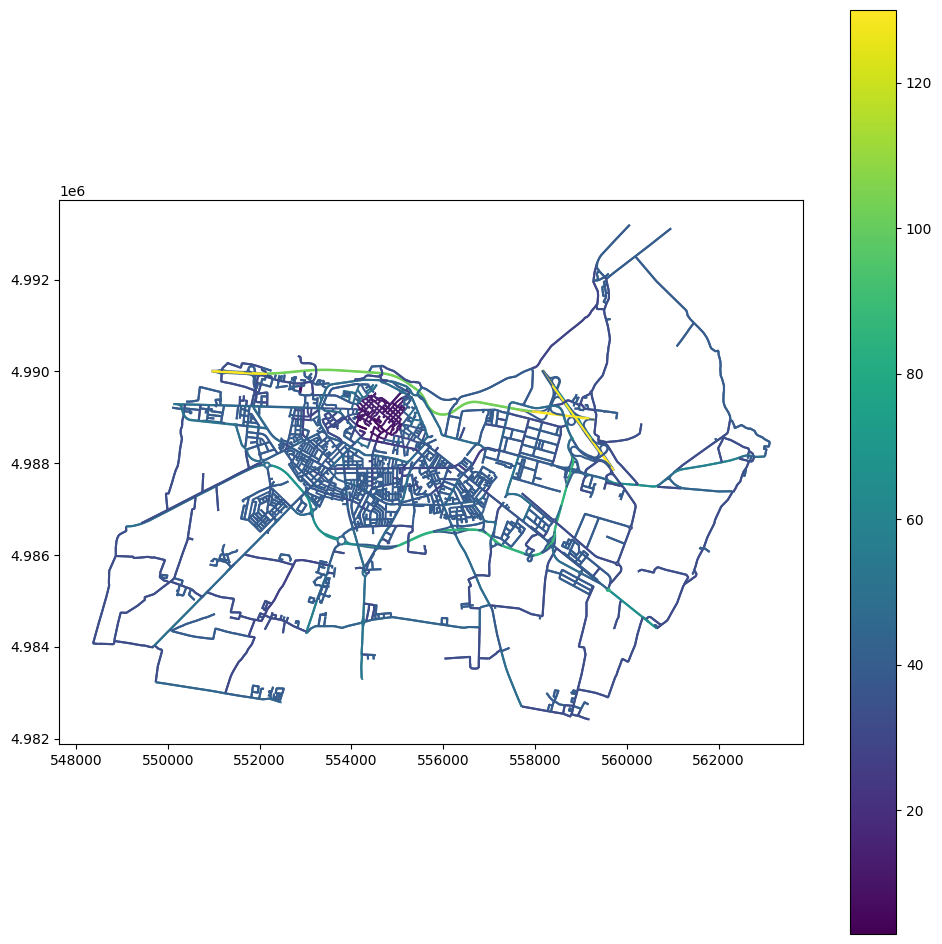

In [100]:
#plot
fig, ax = plt.subplots(figsize=(12,12))
new_gdf_edges.plot(ax=ax, column = 'traffic_speed', cmap='viridis', legend=True)

In [3]:
def city_speed_preprocessing(city_name, which_result=2, center_point_lon=10.02455, center_point_lat=45.13421, name_file = None):
    # get the graph
    graph = ox.graph_from_place(city_name, network_type='drive', which_result= which_result)
    graph = ox.project_graph(graph)
    graph = ox.add_edge_speeds(graph)
    graph = ox.add_edge_travel_times(graph)
    gdf_nodes, gdf_edges = ox.graph_to_gdfs(graph)

    #BC
    print("Computing betweenness centrality")
    bc = nx.betweenness_centrality(graph, weight='length')
    edge_bc = nx.edge_betweenness_centrality(graph, weight='length')
    scaler = MinMaxScaler()
    # scale the values between 0 and 1
    bc = scaler.fit_transform(pd.DataFrame(bc.values()))
    edge_bc = scaler.fit_transform(pd.DataFrame(edge_bc.values()))
    print("Betweenness centrality computed")
    # add the betweenness centrality to the nodes and edges
    gdf_nodes['bc'] = bc
    gdf_edges['edge_bc'] = edge_bc

    # get traffic lights
    traffic_lights = ox.features_from_place(city_name, tags={'highway':'traffic_signals'}, which_result= which_result)
    traffic_lights = traffic_lights.to_crs(gdf_nodes.crs)
    # nearest nodes
    nearest_nodes = ox.distance.nearest_nodes(graph, traffic_lights.geometry.x, traffic_lights.geometry.y)
    gdf_nodes['traffic_lights'] = gdf_nodes.index.isin(nearest_nodes)
    gdf_edges['traffic_lights'] = gdf_edges.index.get_level_values(1).isin(gdf_nodes[gdf_nodes['traffic_lights']].index)

    center_point = shapely.geometry.Point(center_point_lon, center_point_lat)
    center_point_gdf = gpd.GeoDataFrame(geometry=[center_point], crs="EPSG:4326")
    center_point_gdf = center_point_gdf.to_crs(gdf_nodes.crs)
    # add a buffer of 300 meters
    buffer = center_point_gdf.buffer(300)
    gdf_edges_clip = gdf_edges.clip(buffer.geometry[0])
    gdf_edges['traffic_center'] = gdf_edges.index.isin(gdf_edges_clip.index)
    # add the traffic speed
    gdf_edges['traffic_speed'] = gdf_edges['speed_kph']*(1-gdf_edges['edge_bc']*0.7)*(1-gdf_edges['traffic_lights']*0.2)*(1-gdf_edges['traffic_center']*0.7)
    gdf_edges['traffic_time'] = gdf_edges['length'] / (gdf_edges['traffic_speed'] * 1000 / 3600)
    #save to GeoJSON
    gdf_nodes.to_file("nodes_" + name_file + ".geojson", driver='GeoJSON')
    gdf_edges.to_file("edges_" + name_file + ".geojson", driver='GeoJSON')
    return gdf_nodes, gdf_edges

In [21]:
nodes, edges = city_speed_preprocessing("Ferrara", which_result=2, center_point_lon= 11.6186451, center_point_lat= 44.8372737, name_file = "FE")

Computing betweenness centrality
Betweenness centrality computed


<Axes: >

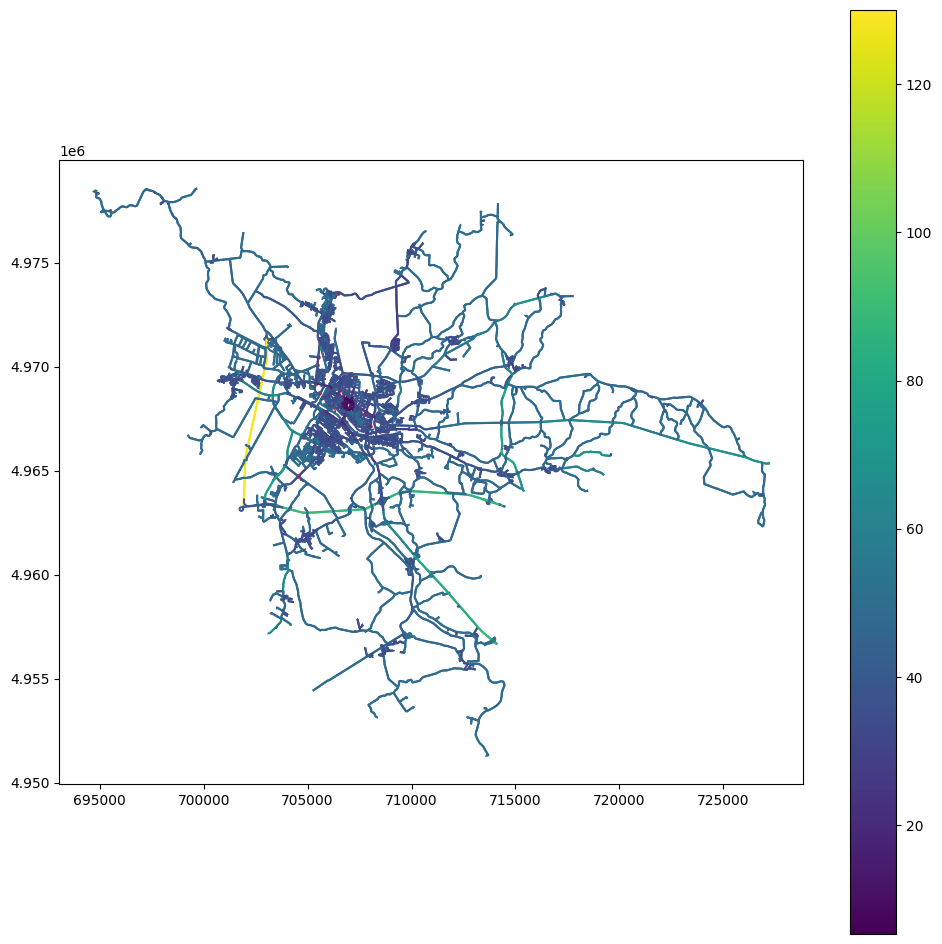

In [22]:
#plot 
fig, ax = plt.subplots(figsize=(12,12))
edges.plot(ax=ax, column = 'traffic_speed', cmap='viridis', legend=True)
#plot traffic lights
nodes[nodes['traffic_lights'] == True].plot(ax=ax, color='red', markersize=5)
